# Test Numba framework

In [3]:
import os
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, vectorize
from platosim.simfile import SimFile

---
## Test solar oscillation script
---

In [13]:
@njit
def pulsations(time, freq, eta, Ntime, Nmode, amplsin, amplcos, 
               kicktimestep, kick_amplitude, last_kicktime, next_kicktime):
    
    signal = np.zeros(Ntime)

    for j in range(Ntime):

        # Compute the contribution of each mode separatly

        for i in range(Nmode):

            # Let the oscillator evolve until right before 'time[j]'

            while (next_kicktime[i] <= time[j]):

                deltatime = next_kicktime[i] - last_kicktime[i]
                damp = np.exp(-eta[i] * deltatime)
                amplsin[i] = damp * amplsin[i] + kick_amplitude[i] * np.random.normal(0.,1.)
                amplcos[i] = damp * amplcos[i] + kick_amplitude[i] * np.random.normal(0.,1.)
                last_kicktime[i] = next_kicktime[i]
                next_kicktime[i] = next_kicktime[i] + kicktimestep

            # Now make the last small step until 'time[j]'

            deltatime = time[j] - last_kicktime[i]
            damp = np.exp(-eta[i] * deltatime)
            signal[j] = signal[j] + damp * (amplsin[i] * np.sin(2*np.pi*freq[i]*time[j])    \
                                  + amplcos[i] * np.cos(2*np.pi*freq[i]*time[j]))
            
    # Return the resulting signal
    print("Returning the resulting signal")
    return(signal)

In [14]:
def solarosc(time, freq, ampl, eta):

    Ntime = len(time)
    Nmode = len(freq)

    print("Simulating %d modes" % Nmode)

    # Set the kick (= reexcitation) timestep to be one 100th of the
    # shortest damping time. (i.e. kick often enough).

    kicktimestep = (1.0 / max(eta)) / 100.0

    print("Oscillation kicktimestep: %f" % kicktimestep)

    # Init start values of amplitudes, and the kicking amplitude
    # so that the amplitude of the oscillator will be on average be
    # constant and equal to the user given amplitude

    amplcos = 0.0
    amplsin = 0.0
    kick_amplitude = ampl * np.sqrt(kicktimestep * eta)

    # Warm up the stochastic excitation simulator to forget the
    # initial conditions. Do this during the longest damping time.
    # But put a maximum on the number of kicks, as there might
    # be almost-stable modes with damping time = infinity

    damp = np.exp(-eta * kicktimestep)
    Nwarmup = min(20000, int(math.floor(1.0 / np.min(eta) / kicktimestep)))
    
    print("%d kicks for warm up for oscillation signal" % Nwarmup)
  
    for i in range(Nwarmup):
        amplsin = damp * amplsin + np.random.normal(np.zeros(Nmode), kick_amplitude)
        amplcos = damp * amplcos + np.random.normal(np.zeros(Nmode), kick_amplitude)
        
    # Initialize the last kick times for each mode to be randomly chosen
    # a little before the first user time point. This is to avoid that
    # the kicking time is always exactly the same for all of the modes.

    last_kicktime = np.random.uniform(time[0] - kicktimestep, time[0], Nmode)
    next_kicktime = last_kicktime + kicktimestep

    print("Simulating stochastic oscillations")
    
    signal = pulsations(time, freq, eta, Ntime, Nmode, amplsin, amplcos, 
                        kicktimestep, kick_amplitude, last_kicktime, next_kicktime)
    
    return signal

In [15]:
# USER PARAMETERS

tdur  = 88. * 86400 * 1e-6 
tstep = 25. * 1e-6

time = np.arange(0, tdur, tstep)
data = np.loadtxt(os.getcwd() + '/solarosc_data.txt')
freq = data[:,0]
ampl = data[:,1]
eta  = data[:,2]

In [16]:
%time signal_puls = solarosc(time, freq, ampl, eta)

Simulating 96 modes
Oscillation kicktimestep: 0.000064
20000 kicks for warm up for oscillation signal
Simulating stochastic oscillations
Returning the resulting signal
CPU times: user 4.37 s, sys: 10.1 ms, total: 4.38 s
Wall time: 4.36 s


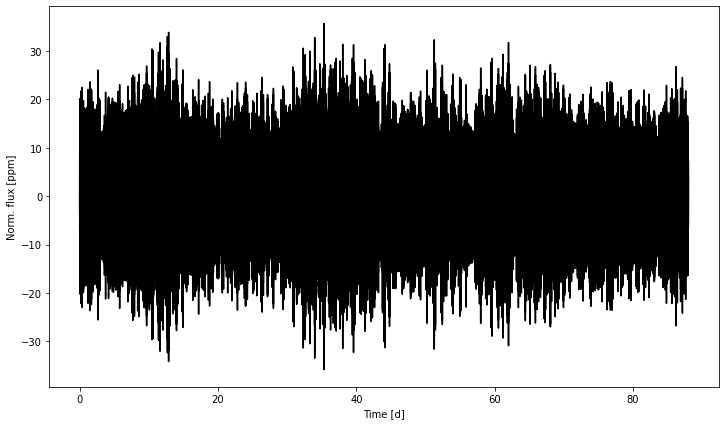

In [20]:
plt.figure(figsize=(12,7))
plt.plot(time*1e6/86400, signal_puls, 'k-')
plt.xlabel('Time [d]')
plt.ylabel('Norm. flux [ppm]')
plt.show()

---
## Test noise model
---

In [46]:
@njit
def simRedNoise(time, timescale, varscale, kicktimestep, 
                Ntime, noise, mu, sigma):

    print("Simulating red noise component(s)")

    delta = 0.0
    signal = np.zeros(Ntime)
    currenttime = time[0] - kicktimestep

    for i in range(Ntime):

        # Compute the contribution of each component separately.
        # First advance the time series right *before* the time point i

        print(mu)
        print(sigma)
        #print(np.random.normal(mu, sigma))
            
        while (currenttime + kicktimestep) < time[i]:
            noise = noise * (1.0 - kicktimestep / timescale) #+ np.random.normal(mu, sigma)
            currenttime = currenttime + kicktimestep

        # Then advance the time series with a small time step right *on* time[i]

        delta = time[i] - currenttime
        sigma = np.sqrt(delta/timescale)*varscale
        noise = noise * (1.0-delta/timescale) #+ np.random.normal(mu, sigma)
        currenttime = time[i]

        # Add the different components to the signal

        signal[i] = np.sum(noise)
        break
    return signal

In [47]:
def modelRedNoiseTimeSeries(time, timescale, varscale):
    """
    PURPOSE : Creates a time series of multi-component red noise.

    INPUT   : time[0..Ntime-1]: time points
            : timescale[0..Ncomp-1]: time scale tau of each red noise component
            : varscale[0..Ncomp-1]: variation scale of each red noise component

    OUTPUT  : signal[0..Ntime-1]: signal containing all red noise components

    EXAMPLE :
             >> import numpy as np
             >> from platosim.noise import redNoise
             >> time = np.linspace(0,100,10000)
             >> signal = modelRedNoiseTimeSeries(time, np.array([20.0]), np.array([1.0]))
    """

    Ntime = len(time)
    Ncomp = len(timescale)

    print("Simulating {0} component(s)".format(Ncomp))

    # Set the kick (= excitation) timestep to be one 100th of the
    # shortest noise time scale (i.e. kick often enough).

    kicktimestep = min(timescale) / 100.0
    print("Kicktimestep = {0}".format(kicktimestep))

    # Predefine some arrays

    noise = np.zeros(Ncomp)
    mu    = np.zeros(Ncomp)
    sigma = np.sqrt(kicktimestep/timescale)*varscale

    # Warm up the first-order autoregressive process

    print("Warming up...")

    for i in range(2000):
        noise = noise * (1.0 - kicktimestep / timescale) + np.random.normal(mu, sigma)

    # Start simulating the granulation time series

    signal = simRedNoise(time, timescale, varscale, kicktimestep, 
                         Ntime, noise, mu, sigma)

    # That's it!

    return signal

In [48]:
# CREATE DATA SET


time = np.arange(0, 1.*86400, 25) * 1e-6   # [Ms]
timescale = np.array([25.0, 2.0]) * 1e-6   # [Ms]
varscale  = np.array([1.1, 1.5]) * 1e-6    # [ppm]

%time signal_noise = modelRedNoiseTimeSeries(time, timescale, varscale)  

Simulating 2 component(s)
Kicktimestep = 2e-08
Warming up...
Simulating red noise component(s)
[0. 0.]
[3.11126984e-08 1.50000000e-07]
CPU times: user 552 ms, sys: 4.83 ms, total: 557 ms
Wall time: 545 ms


In [ ]:
freq_white, PSD_white = powerDensityFFT(noise_white, np.diff(time_white)[0]) 

fig = plt.figure(figsize=(8,4))
plotPSD(fig, freq_white, PSD_white, carbox=False, linewidth=2, #xlim=[1e2, freq_white[-1]], ylim=[1e-18, 1e-6],
        colors=['tomato'], units=['$\mu$Hz', 'arcsec'], title='PSD Jitter white noise')
plt.show()

---
## Test simple filter function
---

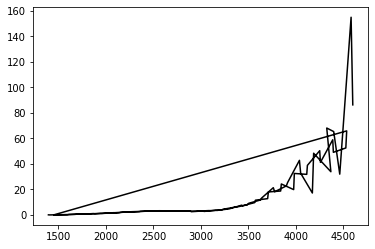

In [11]:
# Import solar-like oscillation file

data = np.loadtxt(os.getcwd() + '/solarosc_data.txt')

plt.plot(data[:,0], data[:,2], 'k-')
plt.show()

In [12]:
@njit
def xfilter(signal, filt='median', carBox=100):
    
    # Constants
    n     = carBox
    S     = signal.copy()     # Avoid overwritting the input signal
    S_new = np.zeros(len(S))  # Prepare forloop
    nzero = np.zeros(2*n+1)   # Optimization constant
    
    
    for i in range(len(S)-2*n):

        # Interval: d[n, 1+n, ... , N-1, N-n]
        
        if filt=='median': S_new[n+i] = np.median(S[np.arange((n+i)-n, (n+i)+n+1)])
        if filt=='mean':   S_new[n+i] = np.mean(S[np.arange((n+i)-n, (n+i)+n+1)])
        if filt=='std':    S_new[n+i] = np.std(S[np.arange((n+i)-n, (n+i)+n+1)])
        
    for i in range(n):

        # Interval: d[-n, -(n-1), ... , n-1, n] - Low end of data

        low = nzero
        low[np.arange(n-i)] = S[0]*np.ones(n-i)
        low[-(n+1+i):] = S[np.arange(0, n+1+i)]
        
        if conv=='median': S_new[i] = np.median(low)
        if conv=='mean':   S_new[i] = np.mean(low)
        if conv=='std':    S_new[i] = np.std(low)

        # Interval: d[N-n, N-(n-1), ... , N+(n-1), N+n] - High end of data

        high = nzero
        high[np.arange(n+1+i)] = S[np.arange(len(S)-(n+i+1), len(S))]
        high[-(n-i):]      = S[-1]*np.ones(n-i)
        
        if conv=='median': S_new[len(S)-1-i] = np.median(high)
        if conv=='mean':   S_new[len(S)-1-i] = np.mean(high)
        if conv=='std':    S_new[len(S)-1-i] = np.std(high)
    
    return S_new

    

In [231]:
%time flux_med = convolution(flux, 'std', 144)

CPU times: user 2.06 s, sys: 7.93 ms, total: 2.07 s
Wall time: 2.08 s


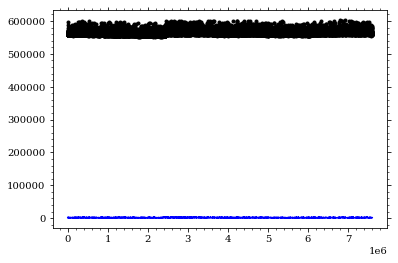

In [232]:
plt.plot(time, flux, 'k.')
plt.plot(time, flux_med, 'b-')